c:\Users\vikra\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,929 (128.63 KB)

 Trainable params: 32,929 (128.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - loss: 0.1005 - val_loss: 0.0035
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - loss: 0.0660 - val_loss: 0.0120
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 0.0531 - val_loss: 0.0162
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - loss: 0.0656 - val_loss: 0.0118
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step
MAE: 0.1741
MSE: 0.0497
RMSE: 0.2228
R² Score: -0.9678
Approx. Accuracy: 82.59%
   Actual Price  Predicted Price  Difference
0      0.186051        -0.001367    0.187418
1      0.460379        -0.006264    0.466643
2      0.113520        -0.016510    0.130030
3      0.471974         0.062856    0.409117
4      0.033715         0.089413    0.055698
5      0.250512         0.132967    0.117545
6      0.096252         0.076244    0.020008
7      0.006852         0.134307    0.127455
8      0.066054         0.181656    0.115602
9      0.091928         0.203820    0.111892


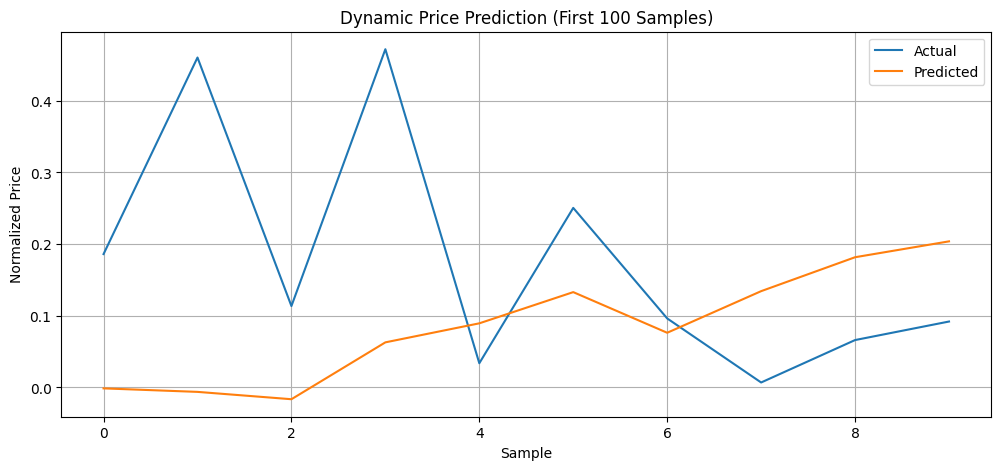

In [3]:
# STEP 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

# STEP 2: Load & Sort Data
df = pd.read_csv(r"C:\Users\vikra\Downloads\dynamic_pricing_dataset.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d-%m-%Y %H:%M') # Specify the correct format for your timestamp data
df = df.sort_values(by=['product_id', 'timestamp'])

# STEP 3: Feature Engineering
df['price_vs_competitor'] = df['current_price'] - df['competitor_price']
df['profit_margin'] = (df['current_price'] - df['cost_price']) / (df['cost_price'] + 1e-5)
df['log_sales_volume'] = np.log1p(df['sales_volume'])
df['log_inventory_level'] = np.log1p(df['inventory_level'])
df['inventory_bin'] = pd.qcut(df['inventory_level'], q=3, labels=['low', 'medium', 'high'])

# STEP 4: Encode Categorical Features
label_encoders = {}
for col in ['product_id', 'category', 'brand', 'season', 'inventory_bin']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# STEP 5: Drop & Normalize
df.drop(['product_name'], axis=1, inplace=True)

scaler = MinMaxScaler()
num_cols = [
    'current_price', 'cost_price', 'competitor_price',
    'price_vs_competitor', 'profit_margin',
    'log_sales_volume', 'log_inventory_level',
    'demand_factor', 'dynamic_price'
]
df[num_cols] = scaler.fit_transform(df[num_cols])

# STEP 6: Sequence Creation
def create_sequences(df, seq_length=10):
    X, y = [], []
    feature_cols = df.columns.drop(['timestamp', 'dynamic_price'])
    grouped = df.groupby('product_id')
    for _, group in grouped:
        group = group.sort_values('timestamp')
        for i in range(len(group) - seq_length):
            X_seq = group.iloc[i:i+seq_length][feature_cols].values
            y_seq = group.iloc[i+seq_length]['dynamic_price']
            X.append(X_seq)
            y.append(y_seq)
    return np.array(X), np.array(y)

sequence_length = 10
X, y = create_sequences(df, sequence_length)

# STEP 7: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

# STEP 8: Build LSTM Model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# STEP 9: Train Model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
)

# STEP 10: Evaluation Metrics
y_pred = model.predict(X_test).flatten()
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
accuracy = 100 * (1 - mae)  # valid only if target scaled

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Approx. Accuracy: {accuracy:.2f}%")

# STEP 11: Actual vs Predicted Comparison
comparison_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})
comparison_df['Difference'] = np.abs(comparison_df['Actual Price'] - comparison_df['Predicted Price'])
print(comparison_df.head(10))

# Save to CSV (Optional)
comparison_df.to_csv("price_prediction_comparison.csv", index=False)

# STEP 12: Plot
plt.figure(figsize=(12, 5))
plt.plot(y_test[:100], label='Actual')
plt.plot(y_pred[:100], label='Predicted')
plt.title("Dynamic Price Prediction (First 100 Samples)")
plt.xlabel("Sample")
plt.ylabel("Normalized Price")
plt.legend()
plt.grid(True)
plt.show()
